## Лабораторная работа №2. Временные ряды
### Задачи:
1. С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.
2. Очистить и унифицировать данные: привести к единому временному индексу, обработать пропуски и выбросы.
3. Провести анализ временного ряда: визуализация, проверка стационарности, декомпозиция на тренд, сезонность и остатки, спектральный анализ.
4. Извлечь из временного ряда признаки, полезные для прогнозирования.
5. Построить дерево решений, случайный лес и бустинг. Подобрать гиперпараметры через optuna. Использовать рекурсивную стратегию и стратегию создания модели на каждый из горизонтов. Сравнить результаты.
6. Оценить качество прогноза на тестовом отрезке с использованием метрик WAPE, MAE, MAPE, directional accuracy, directional r2.



In [4]:
!pip install -r requirements.txt


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


**Подготовка окружения**

In [5]:
import os
import pandas as pd
import numpy as np
import matplotlib as plt
import seaborn as sns
import openpyxl
import io
from openpyxl.styles import Font



# from openpyxl import Workbook
# empty = Workbook()

from dotenv import load_dotenv
load_dotenv()

file_path = os.getenv("DATA_PATH")
print("Ваш путь: " + file_path)

wb = openpyxl.load_workbook(filename=file_path, data_only=True)









Ваш путь: C:\Users\gizda\OneDrive\Desktop\study\labs\frameworks\frameworks_lab2\data\have_fun.xlsx


### 1. С помощью библиотек (openpyxl, pandas) получить доступ ко всем листам Excel-файла.

In [6]:
print("До: " + str(wb.worksheets))

def fix_encoding(text):
    try:
        return text.encode('latin1').decode('cp1251')
    except:
        return text

for sheet in wb.worksheets:
    sheet.title = fix_encoding(sheet.title)
print("Исправленные названия листов:")
print(f"Обнаружено листов: {wb.sheetnames}")

# Проверка на скрытые листы
hidden = [s.title for s in wb.worksheets if s.sheet_state == 'hidden']
if hidden:
    print(f"Найдены скрытые листы: {hidden}. их не видно в excel.")
else:
    print("Все листы видны")
    
for sheet in wb.worksheets:
    sheet.sheet_state = 'visible'
    
# удаляем бессмысленные листы
for sheet_name in wb.sheetnames:
    ws = wb[sheet_name]
    
    # Если в первой ячейке первой строки пусто — считаем лист пустым
    # (ws.max_row == 1 и отсутствие данных в ячейке A1)
    if ws.max_row == 1 and ws['A1'].value is None:
        del wb[sheet_name]
        print(f"Лист '{sheet_name}' удален.")
        

# Возвращаем съехавшую часть таблицы 
lost_data_range = wb['Лист2_строковые_NaN_выбросы']['P16':'Y122']

# 2. Определяем, куда вставлять (в конец колонок A, B, C)
# Находим первую свободную строку после основной таблицы
target_row = 1
while ws.cell(row=target_row, column=1).value is not None:
    target_row += 1

# 3. Переносим данные
for row in lost_data_range:
    col_index = 1  # Начинаем с колонки A (1)
    for cell in row:
        # Копируем значение в конец основной таблицы
        ws.cell(row=target_row, column=col_index).value = cell.value
        # Удаляем значение из "неправильного" места
        cell.value = None
        col_index += 1
    target_row += 1
    
    
            

    

    



# Применяем ко всем ячейкам и названиям листов
for ws in wb.worksheets:
    black_font = Font(color="000000")
    ws.title = fix_encoding(ws.title)
    for row in ws.iter_rows():
        for cell in row:
            cell.value = fix_encoding(cell.value)
            cell.font = black_font
            
wb.save("../correct_wb4.xlsx")

# Далее стандартная выгрузка!!!
# НАЧИНАЕТСЯ РАБОТА С PANDAS


data_dict = {}


for ws in wb.worksheets:
    data_dict[ws.title] = pd.DataFrame(list(ws.iter_rows(values_only=True)))
print("\nПредпросмотр данных:")
print("="*50)
i = 1
for name, df in data_dict.items():
    data_dict[name] = df.dropna(axis=1, how='all')
    print(f"\nЛист: '{name}' | {df.shape[0]}x{df.shape[1]}")
    print(df.head(3))
    df.to_csv(f'file{i}.txt', sep='\t', index=False)
    i += 1
    





    



До: [<Worksheet "Ëèñò1">, <Worksheet "Лист1">, <Worksheet "ÌÀÈ">, <Worksheet "ýòî">, <Worksheet "ÿ">, <Worksheet "!">, <Worksheet "Ëèñò2_ñòðîêîâûå_NaN_âûáðîñû">, <Worksheet "Ëèñò3_ñìåøàííûå_òèïû">]
Исправленные названия листов:
Обнаружено листов: ['Лист11', 'Лист1', 'МАИ', 'это', 'я', '!', 'Лист2_строковые_NaN_выбросы', 'Лист3_смешанные_типы']
Найдены скрытые листы: ['Лист2_строковые_NaN_выбросы', 'Лист3_смешанные_типы']. их не видно в excel.
Лист 'Лист1' удален.
Лист 'МАИ' удален.
Лист 'это' удален.
Лист 'я' удален.
Лист '!' удален.

Предпросмотр данных:

Лист: 'Лист11' | 125125x10
                0                     1              2     3         4  \
0  temperature_2m  relative_humidity_2m  precipitation  rain  snowfall   
1             3.8                  82.0            0.0   0.0       0.0   
2            -3.0                  70.0            0.0   0.0       0.0   

             5               6                 7                    8  \
0  weathercode  wind_speed_10m  surface_

### 2. Очистить и унифицировать данные: привести к единому временному индексу, обработать пропуски и выбросы.


In [43]:
CITY_MAP = {
    'БЛАГОВЕЩЕНСК': 'Благовещенск',
    'Благовещенс': 'Благовещенск',
    'Благовещенск': 'Благовещенск',
    'Благовещенскк': 'Благовещенск',
    'благовещенск': 'Благовещенск',
    
    'ГЕЛЕНДЖИК': 'Геленджик',
    'Геленджи': 'Геленджик',
    'Геленджик': 'Геленджик',
    'Геленджикк': 'Геленджик',
    'геленджик': 'Геленджик',
    
    'Мосва': 'Москва',
    'Москва': 'Москва',
    
    'Находка': 'Находка',
    
    'Санкт-Петербург': 'Санкт-Петербург',
    
    'Соч': 'Сочи',
    'Сочи': 'Сочи',
    'Счи': 'Сочи',
    'Сычи': 'Сочи', # Вероятная опечатка
}

# Список ваших датафреймов из data_dict
dfs_raw = list(data_dict.values())

cleaned_dfs = []

for df in dfs_raw:
    # 1. Ищем строку с заголовками. 
    # Ищем первую строку, где   есть 'ds' или 'date' (регистронезависимо)
    header_idx = None
    for i, row in df.iterrows():
        # Преобразуем значения строки в строки и ищем ключевые слова
        if any(str(val).lower().strip() in ['ds', 'date', 'datetime'] for val in row if pd.notna(val)):
            header_idx = i
            break
            
    if header_idx is None:
        continue # Пропускаем лист, если не нашли дату
        
    # 2. Делаем найденную строку заголовками
    df.columns = df.iloc[header_idx]
    df = df.iloc[header_idx+1:].reset_index(drop=True)
    
    
    if 'city' not in df.columns:
        # Если колонки city нет, пробуем взять из имени листа или ставим Unknown
        df['city'] = name 
    else:
        df['city'] = df['city'].fillna('').astype(str).str.strip()
    
        df['city'] = df['city'].map(lambda x: CITY_MAP.get(x, x))
        
    # Удаляем строки, где город не удалось распознать (остался NaN или неизвестное значение)
    # Или можно заменить на 'Unknown', но лучше удалить шум
    df = df[df['city'].notna() & (df['city'] != 'nan')]
    # 3. Оставляем только нужные столбцы (если есть лишние пустые справа)
    # Стандартный набор из вашего файла:
    target_cols = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 
                   'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure', 'ds', 'city']
    
    # Проверяем, какие из целевых колонок есть в данном листе
    existing_cols = [c for c in target_cols if c in df.columns]
    if 'ds' not in existing_cols or 'city' not in existing_cols:
        continue
        
    df = df[existing_cols].copy()
    
    # 4. Чистка типов
    # Заменяем текстовые пропуски на NaN
    df.replace(['нет данных', 'NAN', 'null', 'NA', 'NaN', 'n/a', '?', 'None', 'NULL', '-', ''], np.nan, inplace=True)
    
    # Числовые колонки (все кроме ds и city)
    num_cols = [c for c in existing_cols if c not in ['ds', 'city']]
    for col in num_cols:
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # Дата
    df['ds'] = pd.to_datetime(df['ds'], errors='coerce')
    
    # 5. Удаляем строки, где нет даты
    df = df.dropna(subset=['ds'])
    
    # 6. Если город не указан в строке, но есть в имени листа - можно добавить логику здесь.
    
    cleaned_dfs.append(df)

# Объединяем все очищенные части
if cleaned_dfs:
    df_all = pd.concat(cleaned_dfs, ignore_index=True)
    
    # 1. Удаляем дубликаты
    df_all = df_all.drop_duplicates(subset=['ds', 'city'], keep='first')
    
    # 2. Обработка выбросов (замена на NaN)
    # Используем mask для чистоты кода, но ваш вариант тоже рабочий
    df_all['temperature_2m'] = df_all['temperature_2m'].where(df_all['temperature_2m'].between(-60, 60))
    df_all['relative_humidity_2m'] = df_all['relative_humidity_2m'].where(df_all['relative_humidity_2m'].between(0, 100))
    df_all['surface_pressure'] = df_all['surface_pressure'].where(df_all['surface_pressure'].between(870, 1085))
    df_all['wind_speed_10m'] = df_all['wind_speed_10m'].where(df_all['wind_speed_10m'].between(0, 50))

    # 3. Интерполяция
    # Убедимся, что ds является датой и отсортирован
    df_all['ds'] = pd.to_datetime(df_all['ds'])
    df_all = df_all.sort_values(by=['city', 'ds'])
    
    # Создаем список для хранения обработанных частей
    interpolated_parts = []
    
    # Группируем по городу
    for city_name, group in df_all.groupby('city'):
        # Устанавливаем дату как индекс для интерполяции по времени
        group = group.set_index('ds')
        
        # Интерполируем числовые колонки
        # Выбираем только числовые колонки для интерполяции
        num_cols_to_interp = ['temperature_2m', 'relative_humidity_2m', 'precipitation', 
                              'rain', 'snowfall', 'weathercode', 'wind_speed_10m', 'surface_pressure']
        
        # Фильтруем только те колонки, которые есть в группе
        existing_num_cols = [c for c in num_cols_to_interp if c in group.columns]
        
        if existing_num_cols:
            group[existing_num_cols] = group[existing_num_cols].interpolate(method='time', limit_direction='both')
        
        # Сбрасываем индекс, чтобы ds снова стал колонкой
        group = group.reset_index()
        interpolated_parts.append(group)
        
    # Склеиваем обратно
    if interpolated_parts:
        df_all = pd.concat(interpolated_parts, ignore_index=True)
    else:
        df_all = pd.DataFrame() # Если вдруг пусто

    # 4. Финальная очистка и сортировка
    if not df_all.empty:
        # Сортируем по городу и дате
        df_all = df_all.sort_values(by=['city', 'ds']).reset_index(drop=True)
        
        # Устанавливаем ds как индекс для удобства дальнейшего анализа
        df_all = df_all.set_index('ds')
        
        print(f"Готово. Строк: {len(df_all)}")
        print(f"Города: {df_all['city'].unique()}")
        print(df_all.head())
    else:
        print("Датафрейм пуст после интерполяции")
else:
    print("Не удалось очистить ни один лист")

Готово. Строк: 368066
Города: <StringArray>
['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']
Length: 6, dtype: str
0                    temperature_2m  relative_humidity_2m  precipitation  \
ds                                                                         
2019-01-01 00:00:00           -13.7                  56.0            0.0   
2019-01-01 01:00:00           -13.2                  56.0            0.0   
2019-01-01 02:00:00           -12.5                  56.0            0.0   
2019-01-01 03:00:00           -12.1                  56.0            0.0   
2019-01-01 04:00:00           -11.9                  56.0            0.0   

0                    rain  snowfall  weathercode  wind_speed_10m  \
ds                                                                 
2019-01-01 00:00:00   0.0       0.0          3.0       12.600000   
2019-01-01 01:00:00   0.0       0.0          3.0       16.299999   
2019-01-01 02:00:00   0.0       0.0          3.0   

In [44]:
print(df_all.head())

0                    temperature_2m  relative_humidity_2m  precipitation  \
ds                                                                         
2019-01-01 00:00:00           -13.7                  56.0            0.0   
2019-01-01 01:00:00           -13.2                  56.0            0.0   
2019-01-01 02:00:00           -12.5                  56.0            0.0   
2019-01-01 03:00:00           -12.1                  56.0            0.0   
2019-01-01 04:00:00           -11.9                  56.0            0.0   

0                    rain  snowfall  weathercode  wind_speed_10m  \
ds                                                                 
2019-01-01 00:00:00   0.0       0.0          3.0       12.600000   
2019-01-01 01:00:00   0.0       0.0          3.0       16.299999   
2019-01-01 02:00:00   0.0       0.0          3.0       18.000000   
2019-01-01 03:00:00   0.0       0.0          3.0       18.100000   
2019-01-01 04:00:00   0.0       0.0          3.0       17.6

In [45]:
df_all["city"].unique()
df_all[df_all["city"] == "Москва"].head(5)


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
ds,,,,,,,,,
2019-01-01 00:00:00,-6.5,92.0,0.0,0.0,0.0,3.0,10.8,1000.500000,Москва
2019-01-01 01:00:00,-6.8,92.0,0.0,0.0,0.0,3.0,10.5,1000.299988,Москва
2019-01-01 02:00:00,-6.8,92.0,0.0,0.0,0.0,3.0,10.8,1000.000000,Москва
2019-01-01 03:00:00,-5.8,93.0,0.0,0.0,0.0,3.0,12.2,999.299988,Москва
2019-01-01 04:00:00,-5.8,93.0,0.0,0.0,0.0,3.0,14.4,998.599976,Москва


### 3. Провести анализ временного ряда: визуализация, проверка стационарности, декомпозиция на тренд, сезонность и остатки, спектральный анализ.

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import signal
from statsmodels.tsa.stattools import adfuller

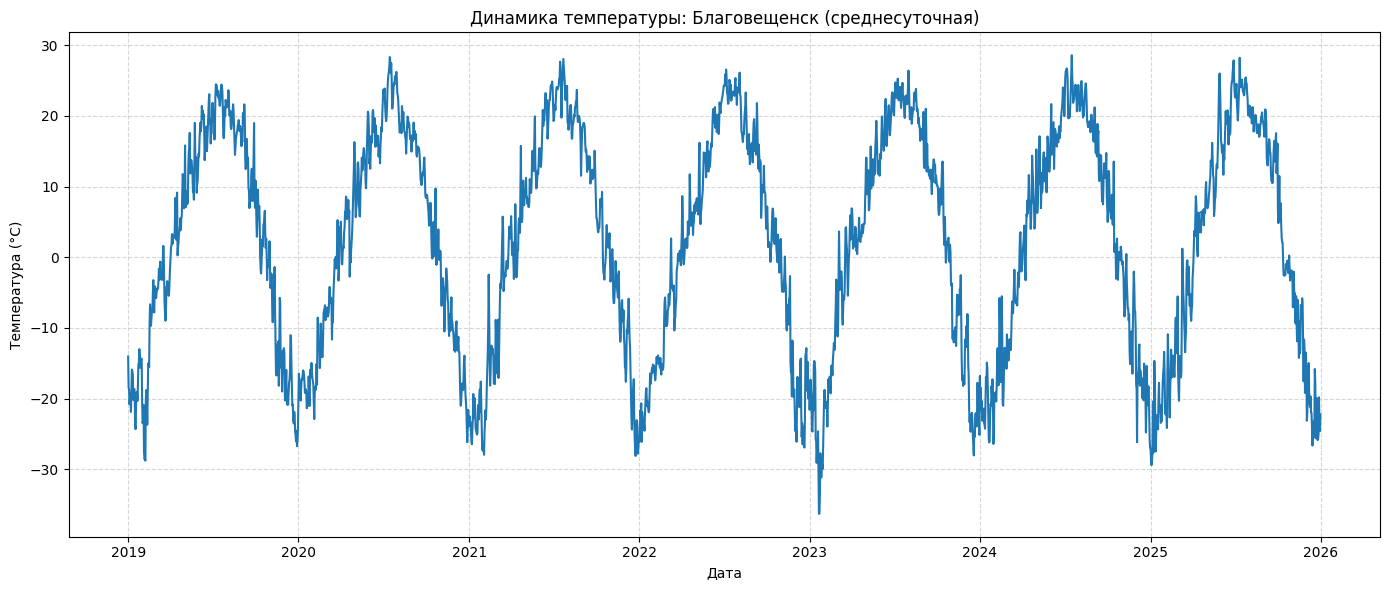

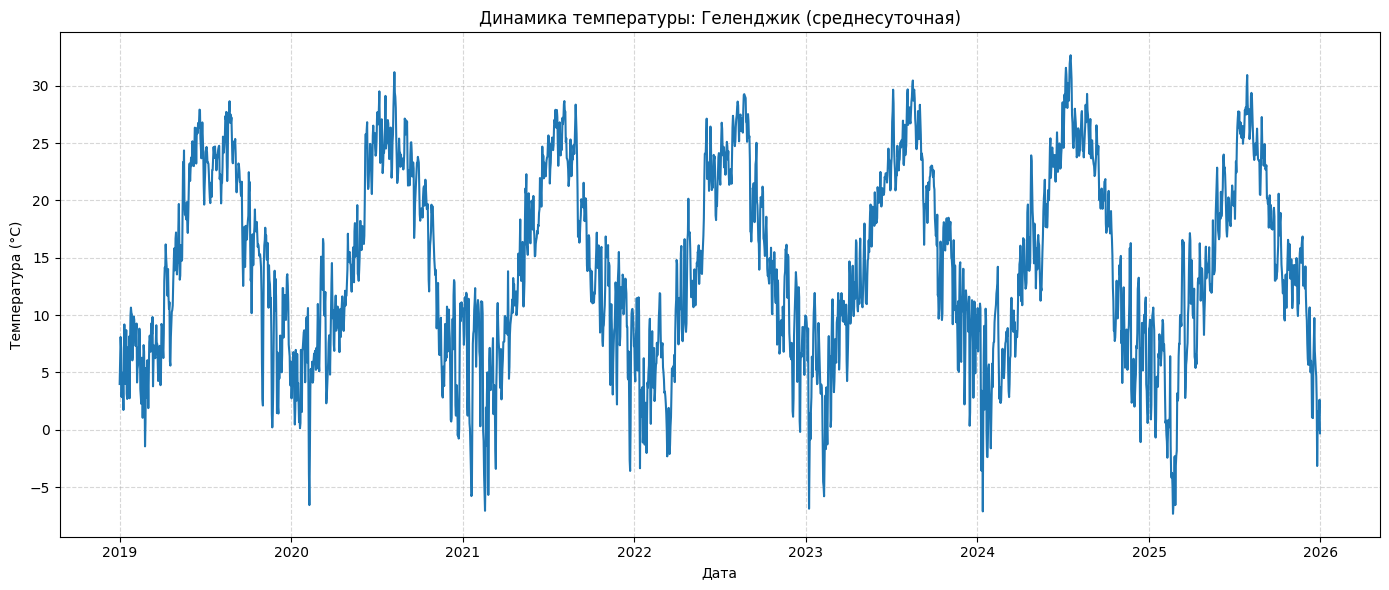

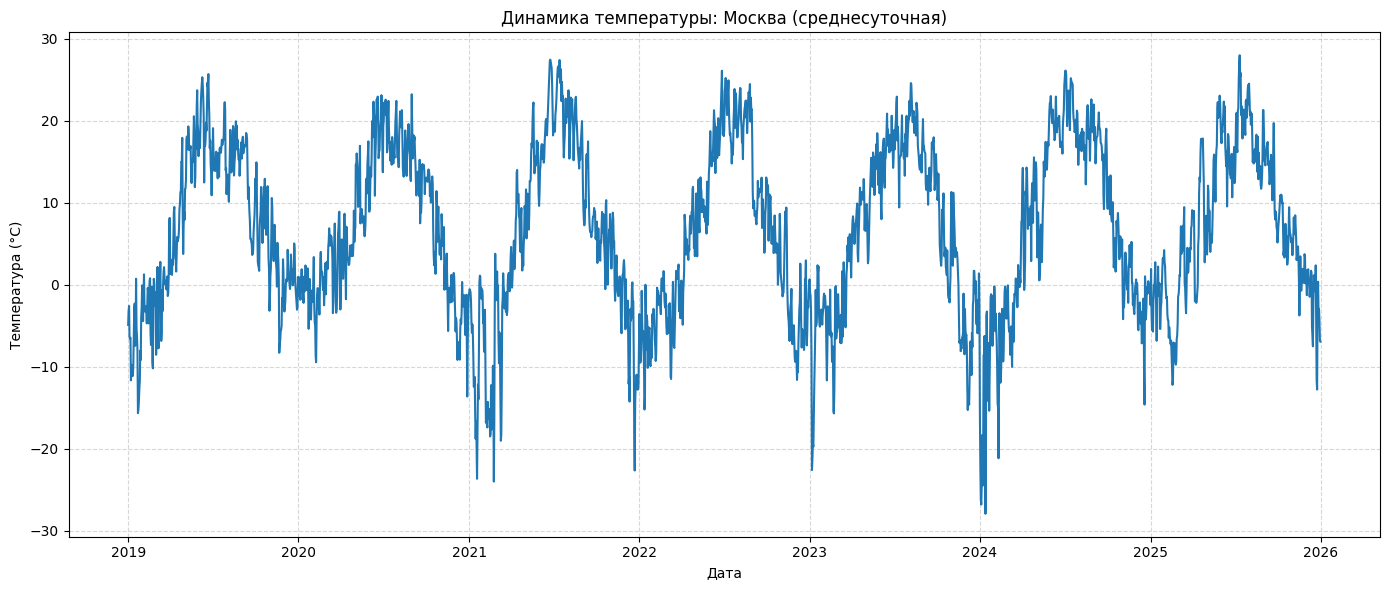

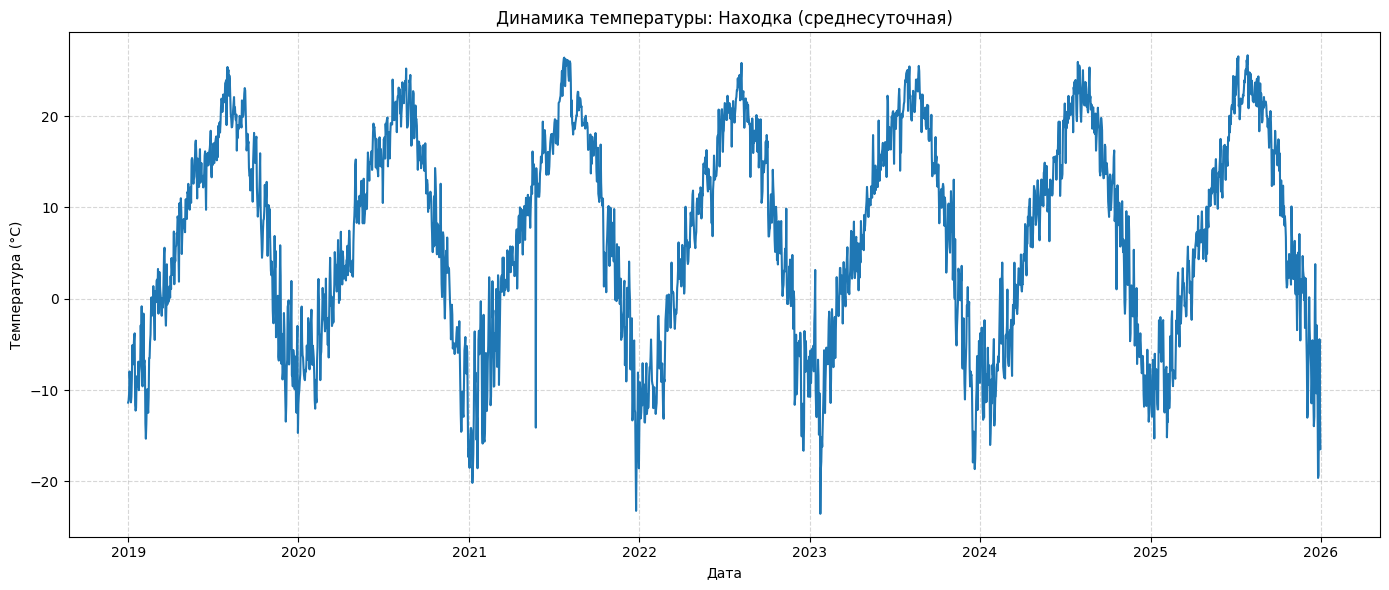

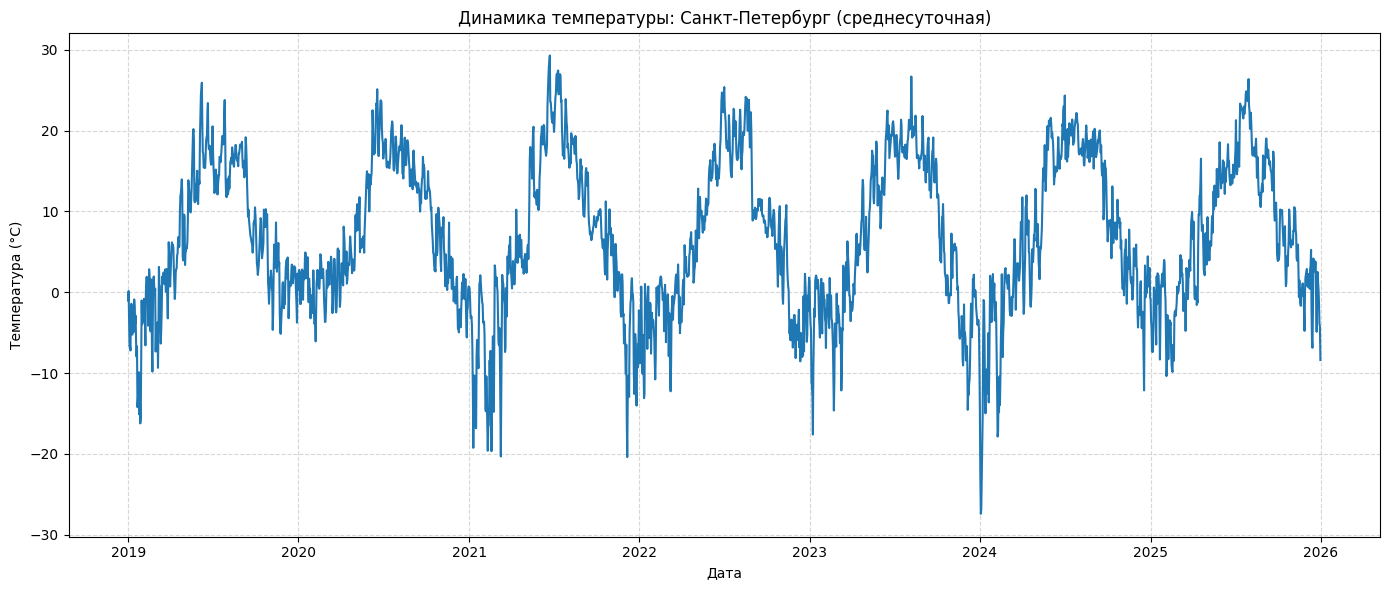

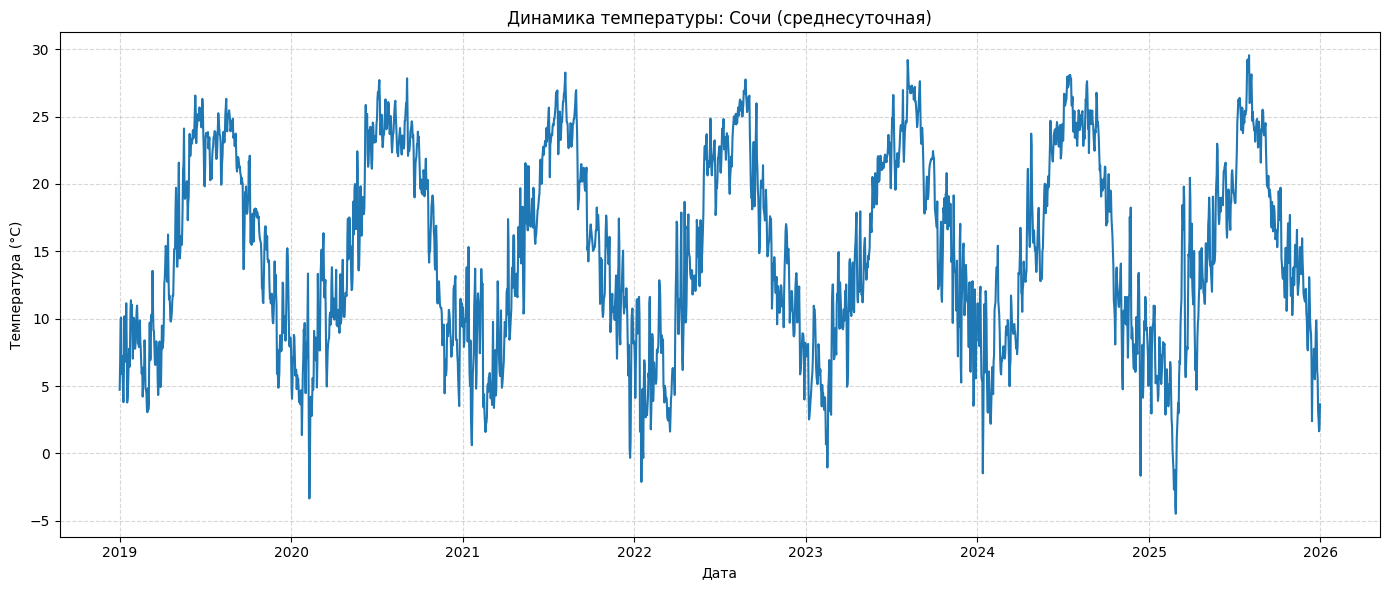

In [47]:
df_temp = df_all[['temperature_2m', 'city']].reset_index() 

cities = ['Благовещенск', 'Геленджик', 'Москва', 'Находка', 'Санкт-Петербург', 'Сочи']

for city in cities:
    # Фильтруем данные по городу
    df_city = df_temp[df_temp["city"] == city].copy()
    
    # Убеждаемся, что ds — это datetime, и ставим его в индекс
    df_city['ds'] = pd.to_datetime(df_city['ds'])
    df_city = df_city.set_index('ds')
    
    # Усредняем данные (например, 'D' — день, 'W' — неделя)
    df_resampled = df_city['temperature_2m'].resample("D").mean().reset_index()

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=df_resampled, x='ds', y='temperature_2m')
    plt.title(f'Динамика температуры: {city} (среднесуточная)')
    plt.xlabel('Дата')
    plt.ylabel('Температура (°C)')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()
    
    
    
    

ADF: stat=-3.156, p=0.0227 | Стационарен


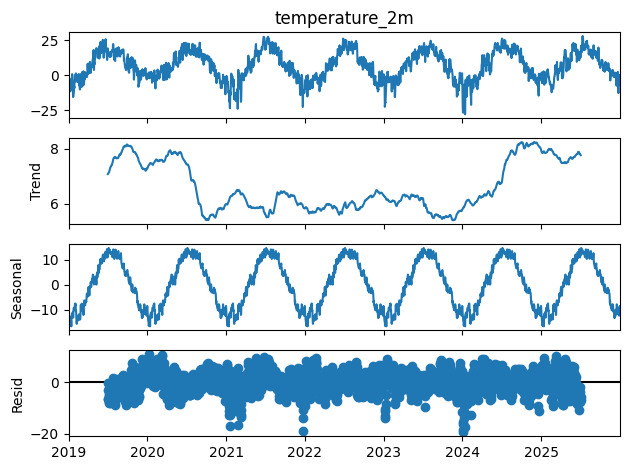

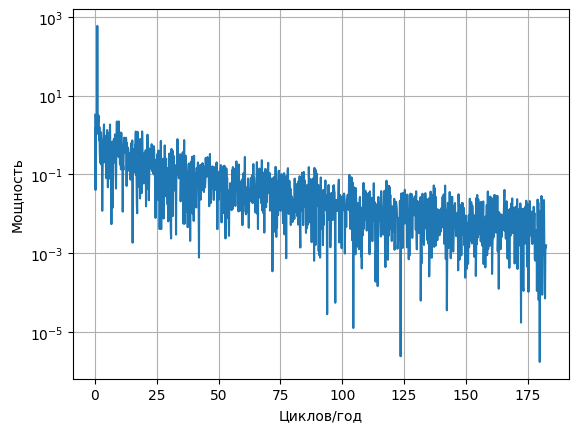

In [48]:
ts = df_all[df_all['city'] == 'Москва']['temperature_2m'].dropna().resample('D').mean().dropna()

# 1. ADF-тест
adf = adfuller(ts)
print(f"ADF: stat={adf[0]:.3f}, p={adf[1]:.4f} | {'Стационарен' if adf[1]<0.05 else 'Нестационарен'}")

# 2. Декомпозиция
sm.tsa.seasonal_decompose(ts, model='additive', period=365).plot()
plt.tight_layout()
plt.show()

# 3. Спектр
f, p = signal.periodogram(ts.values, fs=365)
plt.figure()
plt.semilogy(f[1:], p[1:])
plt.xlabel('Циклов/год'); plt.ylabel('Мощность'); plt.grid(True)
plt.show()

### 4. Извлечь из временного ряда признаки, полезные для прогнозирования. (Feature Engineering)

In [49]:

df_all.head()


,temperature_2m,relative_humidity_2m,precipitation,rain,snowfall,weathercode,wind_speed_10m,surface_pressure,city
ds,,,,,,,,,
2019-01-01 00:00:00,-13.7,56.0,0.0,0.0,0.0,3.0,12.600000,1008.700012,Благовещенск
2019-01-01 01:00:00,-13.2,56.0,0.0,0.0,0.0,3.0,16.299999,1008.500000,Благовещенск
2019-01-01 02:00:00,-12.5,56.0,0.0,0.0,0.0,3.0,18.000000,1008.299988,Благовещенск
2019-01-01 03:00:00,-12.1,56.0,0.0,0.0,0.0,3.0,18.100000,1007.900024,Благовещенск
2019-01-01 04:00:00,-11.9,56.0,0.0,0.0,0.0,3.0,17.600000,1007.500000,Благовещенск


In [36]:
# 1. Агрегация до дневных значений
# Важно: сбрасываем индекс, чтобы city и ds стали обычными колонками
df_daily = df_all[['temperature_2m', 'city']].groupby('city').resample('D').mean().dropna().reset_index()

# 2. Сортировка обязательна для корректной работы shift/rolling
df_daily = df_daily.sort_values(['city', 'ds']).reset_index(drop=True)

# 3. Векторизированное создание признаков (без apply!)
# Создаем лаги и скользящие окна внутри групп
df_daily['lag_1'] = df_daily.groupby('city')['temperature_2m'].shift(1)
df_daily['roll_m7'] = df_daily.groupby('city')['lag_1'].transform(lambda x: x.rolling(7, min_periods=1).mean())
df_daily['roll_s7'] = df_daily.groupby('city')['lag_1'].transform(lambda x: x.rolling(7, min_periods=1).std())

# Временные признаки из индекса (сначала сделаем ds индексом временно или используем dt accessor)
# Так как ds сейчас колонка, используем dt
df_daily['dow'] = df_daily['ds'].dt.dayofweek
df_daily['sin_m'] = np.sin(2 * np.pi * df_daily['ds'].dt.month / 12)
df_daily['cos_m'] = np.cos(2 * np.pi * df_daily['ds'].dt.month / 12)

# Целевые переменные (будущие значения температуры)
for h in range(1, 8):
    df_daily[f't_{h}'] = df_daily.groupby('city')['temperature_2m'].shift(-h)

# 4. Очистка от NaN (появились из-за shift и rolling)
df_feat = df_daily.dropna().copy()

# 5. Кодировка города
# Теперь колонка city точно есть, так как мы не использовали apply, который её скрывает
df_feat['city_c'] = pd.Categorical(df_feat['city']).codes

# 6. Подготовка X и Y
feat_cols = [c for c in df_feat.columns if c not in ['temperature_2m', 'city', 'ds'] + [f't_{h}' for h in range(1,8)]]
target_cols = [f't_{h}' for h in range(1,8)]

X = df_feat[feat_cols].values
Y = df_feat[target_cols].values

print(f"Фичи готовы. Размер X: {X.shape}, Размер Y: {Y.shape}")
print(f"Признаки: {feat_cols}")

Фичи готовы. Размер X: (15285, 7), Размер Y: (15285, 7)
Признаки: ['lag_1', 'roll_m7', 'roll_s7', 'dow', 'sin_m', 'cos_m', 'city_c']


### 5. Построить дерево решений, случайный лес и бустинг. Подобрать гиперпараметры через optuna. Использовать рекурсивную стратегию и стратегию создания модели на каждый из горизонтов. Сравнить результаты.

In [56]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error
import optuna
import numpy as np

# --- 1. Подготовка данных и разбиение ---
# Хронологическое разбиение 70/15/15
n_samples = len(X)
train_end = int(n_samples * 0.70)
val_end = int(n_samples * 0.85)

X_train, X_val, X_test = X[:train_end], X[train_end:val_end], X[val_end:]
Y_train, Y_val, Y_test = Y[:train_end], Y[train_end:val_end], Y[val_end:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# --- 2. Оптимизация гиперпараметров через Optuna ---
def objective(trial):
    model_type = trial.suggest_categorical('model', ['DT', 'RF', 'GB'])
    
    if model_type == 'DT':
        params = {'max_depth': trial.suggest_int('max_depth', 3, 15)}
        model = DecisionTreeRegressor(**params, random_state=42)
    elif model_type == 'RF':
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 20)
        }
        model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    else: # GB
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 50, 300, step=50),
            'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
            'max_depth': trial.suggest_int('max_depth', 3, 10)
        }
        model = GradientBoostingRegressor(**params, random_state=42)
        
    # Обучаем на первом горизонте (t+1) для быстрой оценки
    model.fit(X_train, Y_train[:, 0])
    preds = model.predict(X_val)
    return mean_absolute_error(Y_val[:, 0], preds)

print("Запуск Optuna...")
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_model_type = best_params.pop('model')
print(f"Лучшая модель: {best_model_type}, Параметры: {best_params}")

# Приводим параметры к виду, понятному sklearn (если Optuna вернул другие имена)
final_params = {}
for k, v in best_params.items():
    final_params[k] = v # В данном коде имена уже совпадают со sklearn

ModelClass = {
    'DT': DecisionTreeRegressor, 
    'RF': RandomForestRegressor, 
    'GB': GradientBoostingRegressor
}[best_model_type]

# --- 3. Обучение финальных моделей ---

# STRATEGY 1: DIRECT (7 независимых моделей)
models_direct = []
for i in range(7):
    m = ModelClass(**final_params, random_state=42)
    m.fit(X_train, Y_train[:, i])
    models_direct.append(m)

Y_pred_direct = np.column_stack([m.predict(X_test) for m in models_direct])

# STRATEGY 2: RECURSIVE (1 модель + цикл)
model_recursive = ModelClass(**final_params, random_state=42)
model_recursive.fit(X_train, Y_train[:, 0]) # Обучаем только на t+1

Y_pred_recursive = np.zeros((X_test.shape[0], 7))
current_X = X_test.copy()

# Находим индексы признаков лага и скользящего среднего в X
idx_lag = feat_cols.index('lag_1')
idx_roll = feat_cols.index('roll_m7')

for h in range(7):
    # Предсказываем текущий шаг
    Y_pred_recursive[:, h] = model_recursive.predict(current_X)
    
    # Обновляем признаки для следующего шага рекурсии
    if h < 6:
        current_X[:, idx_lag] = Y_pred_recursive[:, h]
        # Для roll_m7 в рекурсии сложно пересчитать точно без pandas, 
        # поэтому часто оставляют как есть или используют упрощенную логику.
        # Здесь мы просто обновляем lag_1, что является основным драйвером рекурсии.

print("Модели обучены и прогнозы сделаны.")

[I 2026-05-03 16:32:44,078] A new study created in memory with name: no-name-22e928e7-3201-44a4-8e37-55c2c8dafe28


Train: (10699, 7), Val: (2293, 7), Test: (2293, 7)
Запуск Optuna...


Best trial: 0. Best value: 2.49852:   3%|▎         | 1/30 [00:00<00:27,  1.06it/s]

[I 2026-05-03 16:32:45,024] Trial 0 finished with value: 2.49852338105938 and parameters: {'model': 'RF', 'n_estimators': 250, 'max_depth': 12}. Best is trial 0 with value: 2.49852338105938.


Best trial: 0. Best value: 2.49852:   7%|▋         | 2/30 [00:01<00:23,  1.20it/s]

...

[I 2026-05-03 16:33:03,752] Trial 26 finished with value: 2.4204588626501287 and parameters: {'model': 'RF', 'n_estimators': 200, 'max_depth': 7}. Best is trial 25 with value: 2.416945065531591.


Best trial: 25. Best value: 2.41695:  93%|█████████▎| 28/30 [00:20<00:00,  2.25it/s]

[I 2026-05-03 16:33:04,293] Trial 27 finished with value: 2.4965775419775995 and parameters: {'model': 'RF', 'n_estimators': 150, 'max_depth': 11}. Best is trial 25 with value: 2.416945065531591.


Best trial: 25. Best value: 2.41695: 100%|██████████| 30/30 [00:21<00:00,  1.40it/s]


[I 2026-05-03 16:33:05,478] Trial 28 finished with value: 2.868255380693594 and parameters: {'model': 'GB', 'n_estimators': 50, 'learning_rate': 0.28571821763038147, 'max_depth': 7}. Best is trial 25 with value: 2.416945065531591.
[I 2026-05-03 16:33:05,509] Trial 29 finished with value: 2.5198112374276653 and parameters: {'model': 'DT', 'max_depth': 7}. Best is trial 25 with value: 2.416945065531591.
Лучшая модель: RF, Параметры: {'n_estimators': 100, 'max_depth': 7}
Модели обучены и прогнозы сделаны.


### 6. Оценить качество прогноза на тестовом отрезке с использованием метрик WAPE, MAE, MAPE, directional accuracy, directional r2

In [59]:
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np

# --- Метрики ---
def wape(t, p): 
    return np.sum(np.abs(t - p)) / np.sum(np.abs(t))

def dir_acc(t, p): 
    # Направление изменения: совпадает ли знак разницы между соседними точками
    return np.mean((np.diff(t, axis=0) * np.diff(p, axis=0)) > 0)

def dir_r2(t, p):
    # Коэффициент детерминации для направлений (производных)
    dt, dp = np.diff(t, axis=0), np.diff(p, axis=0)
    return 1 - np.sum((dt - dp)**2) / (np.sum(dt**2) + 1e-9)

def calculate_metrics(y_true, y_pred):
    # Маска для MAPE, чтобы избежать деления на ноль или очень малые числа
    mask = np.abs(y_true) > 0.1
    
    mae = mean_absolute_error(y_true, y_pred)
    w = wape(y_true, y_pred)
    
    # MAPE считаем только там, где температура не близка к нулю
    if np.any(mask):
        mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100
    else:
        mape = np.nan
        
    da = dir_acc(y_true, y_pred)
    dr2 = dir_r2(y_true, y_pred)
    
    return {
        'MAE': mae,
        'WAPE': w,
        'MAPE': mape,
        'DirAcc': da,
        'DirR2': dr2
    }

# --- Расчет метрик для обеих стратегий ---
# Y_te — истинные значения на тесте (из пункта 5)
# Y_pred_direct и Y_pred_recursive — прогнозы (из пункта 5)

metrics_direct = calculate_metrics(Y_te, Y_pred_direct)
metrics_recursive = calculate_metrics(Y_te, Y_pred_recursive)

# Формируем итоговую таблицу
res_df = pd.DataFrame({
    'Direct': metrics_direct,
    'Recursive': metrics_recursive
}).T

print("\nСравнение стратегий прогнозирования на тесте:")
print(res_df.round(4))


Сравнение стратегий прогнозирования на тесте:
              MAE    WAPE     MAPE  DirAcc   DirR2
Direct     2.5918  0.1731  29.5749  0.4703 -0.2682
Recursive  2.5659  0.1714  31.5200  0.4442 -0.3307
